In [ ]:
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
import pickle

from astropy import units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, AltAz, EarthLocation

import visibility_functions as vf

In [2]:
patches = ['center', 'center_right', 'right', 'far_right', 'center_left']
months = ['janfeb', 'marapr', 'mayjun', 'julaug', 'sepoct', 'novdec']

In [ ]:
def _bimestre_tag(month: int) -> str:
    if month in (1, 2):
        return "janfeb"
    if month in (3, 4):
        return "marapr"
    if month in (5, 6):
        return "mayjun"
    if month in (7, 8):
        return "julaug"
    if month in (9, 10):
        return "sepoct"
    if month in (11, 12):
        return "novdec"
    raise ValueError("`month` must be between 1 and 12.")

def _load_pointings_for_patch_month(patch: str, month: int):
    tag = _bimestre_tag(month)
    file = f"/media/mattia/Hard Disk/data/{patch}/pointings/pointings_{tag}.pkl"
    return pickle.load(open(file, 'rb'))
    
def plot_visibility_pointings(patches, year: int, month: int, day: int):
    """
    Plot model visibility curves and measured pointings elevation for selected patches
    over one day (00:00-24:00).

    Parameters
    ----------
    patches : list[str]
        List of patch names (keys of `patches_coordinates`).
    year : int
        Year of the requested local date.
    month : int
        Month of the requested date (1-12).
    day : int
        Day of month of the requested date (1-31).
    """
    el_min = 30 * u.deg
    el_max = 70 * u.deg

    # RA/Dec coordinates for each patch
    patches_coordinates = {
        "center": [266.4049948, -28.93617396],
        "center_right": [245.0, -61.45],
        "right": [128.97122224, -40.66361566],
        "far_right": [79.15775205, 2.71164346],
        "center_left": [319.77042971, 34.47019111],
        "left": [44.97519293, 26.77052821]
    }

    # Define the requested day
    start_utc = Time(f"{year:04d}-{month:02d}-{day:02d} 00:00:00")
    stop_utc = start_utc + 24 * u.hour

    # Observatory location (QUBIC site)
    earth_location = EarthLocation(lat=-24.183333333 * u.deg, lon=-66.466666667 * u.deg)

    # Common time grid (1 point per minute)
    tgrid = np.arange(0, 24 * 3600, 60) * u.s
    frame = AltAz(obstime=start_utc + tgrid, location=earth_location)

    plt.figure(figsize=(14, 6))

    for patch in patches:
        ra, dec = patches_coordinates[patch]
        pointings = _load_pointings_for_patch_month(patch, month)

        start = (start_utc - pointings.date_obs).to_value(u.s)
        end = (stop_utc - pointings.date_obs).to_value(u.s)
        mask_day = (pointings.time >= start) & (pointings.time < end)
        
        eq = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
        path = eq.transform_to(frame)
        plt.plot(tgrid.to_value(u.hour), path.alt.deg, label=f"{patch} (model)")

        plt.scatter((pointings.date_obs + pointings.time[mask_day]*u.s - start_utc).to_value(u.hour), pointings.elevation[mask_day], s=3, label=f"{patch} (pointings)")

    plt.axhline(el_min.to_value(u.deg), color="k", ls="--", lw=1)
    plt.axhline(el_max.to_value(u.deg), color="k", ls="--", lw=1)
    plt.ylim(0, 90)
    plt.xlim(0, 24)
    plt.xlabel("Hour UTC [h]")
    plt.ylabel("Elevation [deg]")
    plt.legend()

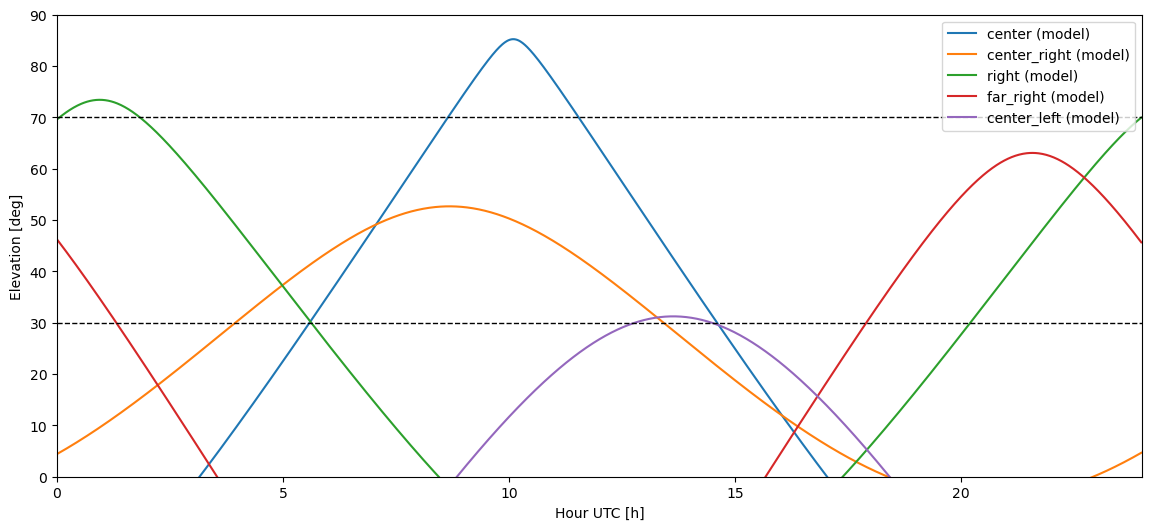

In [5]:
plot_visibility_pointings(patches, 2026, 3, 24)

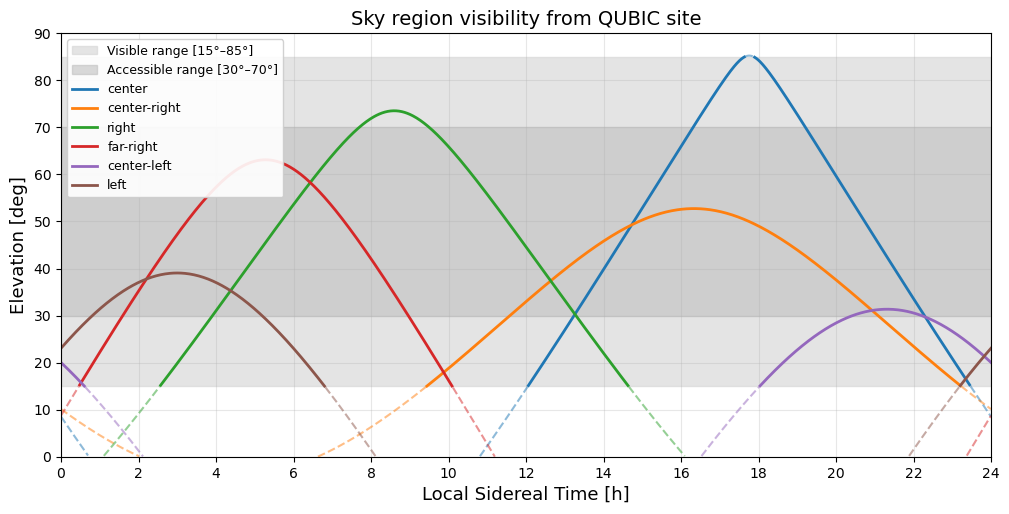

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Site coordinates ──
lat_deg = -24.183333333  # Alto Chorillos latitude [deg]
lat = np.radians(lat_deg)

# ── Patch coordinates: [RA, Dec] in degrees ──
patches_coordinates = {
    "center":       [266.4049948,  -28.93617396],
    "center-right": [245.0,        -61.45],
    "right":        [128.97122224, -40.66361566],
    "far-right":    [79.15775205,   2.71164346],
    "center-left":  [319.77042971,  34.47019111],
    "left":         [44.97519293,   26.77052821],
}

# ── LST array (0 to 24 h) ──
lst_hours = np.linspace(0, 24, 1000)

# ── Compute elevation vs LST for each patch ──
def elevation_vs_lst(ra_deg, dec_deg, lat_rad, lst_h):
    """Compute elevation [deg] as a function of LST [hours]."""
    ra_h = ra_deg / 15.0  # RA in hours
    ha = np.radians((lst_h - ra_h) * 15.0)  # hour angle in radians
    dec = np.radians(dec_deg)
    sin_alt = (np.sin(lat_rad) * np.sin(dec)
               + np.cos(lat_rad) * np.cos(dec) * np.cos(ha))
    alt = np.degrees(np.arcsin(np.clip(sin_alt, -1, 1)))
    return alt

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 5.5))

# Elevation bands
ax.axhspan(15, 85, color="lightgray", alpha=0.6, label="Visible range [15°–85°]")
ax.axhspan(30, 70, color="silver", alpha=0.6, label="Accessible range [30°–70°]")

# Dashed reference lines at band edges
#for el in [15, 85]:
#    ax.axhline(el, color="grey", ls=":", lw=0.8)
#for el in [30, 70]:
#    ax.axhline(el, color="black", ls="--", lw=0.9)

# Visibility curves
colors = {
    "center":       "#1f77b4",
    "center-right": "#ff7f0e",
    "right":        "#2ca02c",
    "far-right":    "#d62728",
    "center-left":  "#9467bd",
    "left":         "#8c564b",
}

for name, (ra, dec) in patches_coordinates.items():
    elev = elevation_vs_lst(ra, dec, lat, lst_hours)

    # Mask below horizon
    elev_above = np.where(elev > 0, elev, np.nan)

    # Inside visible range (15–85°): solid line
    elev_in = np.where((elev >= 15) & (elev <= 85), elev, np.nan)
    # Outside visible range but above horizon: dashed line
    elev_out = np.where((elev > 0) & ((elev < 15) | (elev > 85)), elev, np.nan)

    ax.plot(lst_hours, elev_in,  lw=2,   color=colors[name], ls="-",  label=name)
    ax.plot(lst_hours, elev_out, lw=1.5, color=colors[name], ls="--", alpha=0.5)

# Axes
ax.set_xlim(0, 24)
ax.set_ylim(0, 90)
ax.set_xlabel("Local Sidereal Time [h]", fontsize=13)
ax.set_ylabel("Elevation [deg]", fontsize=13)
ax.set_title("Sky region visibility from QUBIC site", fontsize=14)
ax.set_xticks(np.arange(0, 25, 2))
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
#plt.savefig("/home/claude/visibility_lst.png", dpi=200)
#plt.savefig("/home/mattia/tesi/tesi/figures/visibility_comparison.pdf", bbox_inches='tight')
#print("Done – saved visibility_lst.png and .pdf")